# Phase 2: Physics-Informed Neural Network (PINN)
Welcome to the Brain of the engine. Here, we will train a neural network to approximate the 3D Heat Equation.

### The Goal
Instead of calculating `T_new = T_old + (alpha * dt * laplacian)` over a massive voxel grid, we will train an AI so that we can ask it: `Predict_Temp(x, y, z, time)` and get an instant, continuous answer.

In [103]:
import sys
# Scrub the corrupted local installation
!{sys.executable} -m pip uninstall -y torch torchvision torchaudio
!{sys.executable} -m pip install --no-cache-dir torch --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
   ---------------------------------------- 0.0/122.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/122.9 MB 1.5 MB/s eta 0:01:21
   ---------------------------------------- 0.8/122.9 MB 2.1 MB/s eta 0:00:59
    --------------------------------------- 1.8/122.9 MB 2.6 MB/s eta 0:00:46
    --------------------------------------- 2.6/122.9 MB 2.8 MB/s eta 0:00:43
   - -------------------------------------- 3.1/122.9 MB 2.8 MB/s eta 0:00:44
   - -------------------------------------- 4.2/122.9 MB 3.1 MB/s eta 0:00:38
   - -------------------------------------- 5.0/122.9 MB 3.2 MB/s eta 0:00:37
   - -------------------------------------- 5.5/122.9 MB 3.3 MB/s eta 0:00:36
   -- ------------------------------------- 6.8/122.9 MB 3.5 MB/s eta 0:00:34
   -- ------------------------------------- 7.6/122.9 MB 3.6 MB/s eta 0:00:33
   -- ---------------

In [104]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Check if Google Colab GPU (T4) or local GPU is active
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch Version: {torch.__version__}")
print(f"Using Device: {device}")

PyTorch Version: 2.12.0+cpu
Using Device: cpu


In [105]:



class HeatPINN1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)



        )
    def forward(self,x,t):
         inputs = torch.cat([x, t], dim=1) 
         return self.net(inputs)

        

In [106]:
model=HeatPINN1D()
print(model)


HeatPINN1D(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [107]:
def Calculate_loss(model, x, t, alpha=1.0):
    x.requires_grad_(True)
    t.requires_grad_(True)
    
    T = model(x, t)
    
    # Calculate dT/dt (Notice the 't' added as the second argument!)
    dT_dt = torch.autograd.grad(T, t, grad_outputs=torch.ones_like(T), create_graph=True)[0]
    
    # Calculate d^2T/dx^2
    dT_dx = torch.autograd.grad(T, x, grad_outputs=torch.ones_like(T), create_graph=True)[0]
    d2T_dx2 = torch.autograd.grad(dT_dx, x, grad_outputs=torch.ones_like(dT_dx), create_graph=True)[0]
    
    # Heat equation residual (Left side minus Right side)
    residue = dT_dt - alpha * d2T_dx2
    
    # Return Mean Squared Error
    return torch.mean(residue**2)


Phase 1: Adam mapping the stretched coordinate physics...
Phase 2: L-BFGS carving the extreme thermal gradient...


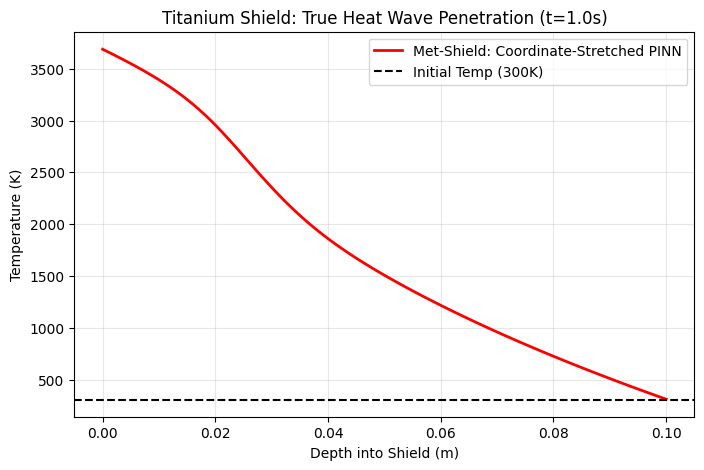

In [108]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- 1. CORE CONSTANTS ---
L = 0.1                
T_INITIAL = 300.0      
ALPHA = 0.0000068      
K_TI = 21.9               
FLUX_TARGET = 500000.0 
T_SCALE = 2000.0       

# --- 2. THE PHYSICS ---
def Calculate_loss(model, x, t, alpha):
    x.requires_grad_(True)
    t.requires_grad_(True)
    T = model(x, t)
    
    dT_dt = torch.autograd.grad(T, t, torch.ones_like(T), create_graph=True)[0]
    dT_dx = torch.autograd.grad(T, x, torch.ones_like(T), create_graph=True)[0]
    d2T_dx2 = torch.autograd.grad(dT_dx, x, torch.ones_like(dT_dx), create_graph=True)[0]
    
    residue = dT_dt - alpha * d2T_dx2
    return torch.mean((residue / T_SCALE)**2)

# --- 3. HARD-CONSTRAINED ARCHITECTURE ---
class MetShield(nn.Module):
    def __init__(self):
        super().__init__()
        # Wider network to handle the sharp exponential decay of the heat wave
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 1)
        )

    def forward(self, x, t):
        # THE FIX: Coordinate Stretching
        # Amplifies the network's internal curvature by 10,000x to handle the stiff PDE
        x_stretched = x /L
        raw_output = self.net(torch.cat([x_stretched, t], dim=1))
        
        # Hard initial condition constraint
        return T_INITIAL + (t * T_SCALE * raw_output)

model = MetShield()

# --- 4. PHASE 1: ADAM ---
print("Phase 1: Adam mapping the stretched coordinate physics...")
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(3000):
    optimizer.zero_grad()
    
    x_p = torch.rand(1000, 1, requires_grad=True) * L
    t_p = torch.rand(1000, 1, requires_grad=True)
    lp = Calculate_loss(model, x_p, t_p, ALPHA)
    
    x_front = torch.zeros(300, 1, requires_grad=True)
    t_front = torch.rand(300, 1)
    pred_front = model(x_front, t_front)
    db_front = torch.autograd.grad(pred_front, x_front, torch.ones_like(pred_front), create_graph=True)[0]
    lb_front = torch.mean(((-K_TI * db_front - FLUX_TARGET) / FLUX_TARGET)**2)
    
    x_back = torch.ones(300, 1) * L 
    t_back = torch.rand(300, 1)
    pred_back = model(x_back, t_back)
    lb_back = torch.mean(((pred_back - T_INITIAL) / T_SCALE)**2)
    
    t_domain = model(x_p, t_p)
    l_floor = torch.mean(torch.relu(T_INITIAL - t_domain)**2)
    
    (1.0 * lp + 100.0 * lb_front + 100.0 * lb_back + 100.0 * l_floor).backward()
    optimizer.step()

# --- 5. PHASE 2: L-BFGS ---
print("Phase 2: L-BFGS carving the extreme thermal gradient...")
optimizer_lbfgs = optim.LBFGS(model.parameters(), lr=1, max_iter=2500, line_search_fn="strong_wolfe")

def closure():
    optimizer_lbfgs.zero_grad()
    
    xl = torch.rand(1000, 1, requires_grad=True) * L
    tl = torch.rand(1000, 1, requires_grad=True)
    l_p = Calculate_loss(model, xl, tl, ALPHA)
    
    xf = torch.zeros(300, 1, requires_grad=True)
    tf = torch.rand(300, 1)
    pred_f = model(xf, tf)
    db_f = torch.autograd.grad(pred_f, xf, torch.ones_like(pred_f), create_graph=True)[0]
    lb_f = torch.mean(((-K_TI * db_f - FLUX_TARGET) / FLUX_TARGET)**2)
    
    xb = torch.ones(300, 1) * L
    tb = torch.rand(300, 1)
    pred_b = model(xb, tb)
    lb_b = torch.mean(((pred_b - T_INITIAL) / T_SCALE)**2)
    
    t_domain = model(xl, tl)
    l_floor = torch.mean(torch.relu(T_INITIAL - t_domain)**2)
    
    total = (1.0 * l_p) + (2000.0 * lb_f) + (2000.0 * lb_b) + (100.0 * l_floor)
    total.backward()
    return total

optimizer_lbfgs.step(closure)

# --- 6. PLOT ---
with torch.no_grad():
    xp = torch.linspace(0, L, 100).view(-1, 1)
    tp = torch.ones_like(xp) * 1.0 
    x_np = xp.detach().numpy()
    y_np = model(xp, tp).detach().numpy()

plt.figure(figsize=(8, 5))
plt.plot(x_np, y_np, 'r-', lw=2, label="Met-Shield: Coordinate-Stretched PINN")
plt.axhline(300, color='k', ls='--', label="Initial Temp (300K)")
plt.title("Titanium Shield: True Heat Wave Penetration (t=1.0s)")
plt.xlabel("Depth into Shield (m)")
plt.ylabel("Temperature (K)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

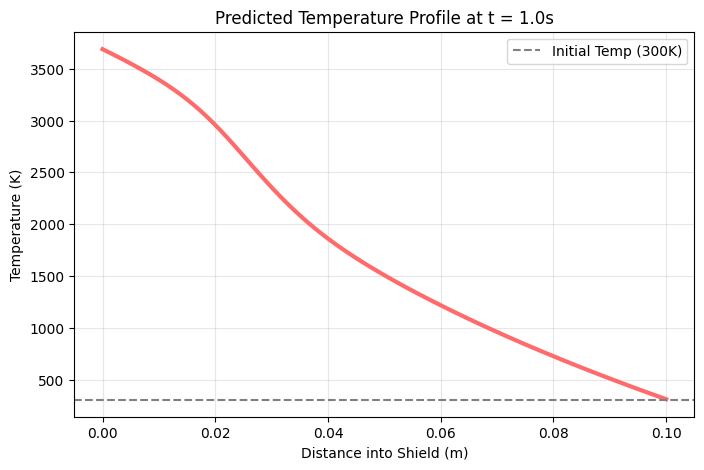

: 

In [ ]:
import numpy as np
import torch.optim as optim
L = 0.1         # Shield thickness in meters (10cm)
T_MAX = 1.0     # Maximum simulation time in seconds
T_INITIAL = 300.0 # Room temperature in Kelvin
# Create a spatial grid from x=0 (plasma) to x=L (back of shield)
x_test = torch.linspace(0, L, 100).view(-1, 1).to(device)
# Check the temperature at the final time step
t_test = torch.ones_like(x_test) * T_MAX 

with torch.no_grad():
    T_pred = model(x_test, t_test).cpu().numpy()

plt.figure(figsize=(8, 5))
plt.plot(x_test.cpu().numpy(), T_pred, color='#FF6B6B', lw=3)
plt.axhline(y=300, color='gray', linestyle='--', label='Initial Temp (300K)')
plt.title("Predicted Temperature Profile at t = 1.0s")
plt.xlabel("Distance into Shield (m)")
plt.ylabel("Temperature (K)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()